# Phase 6 — Multi-Modal Feature Fusion

Horizontally stack sparse TF-IDF text features with tabular features into one fused matrix for modeling.

$$
X_{\\text{fused}} = [\\, X_{\\text{tfidf}} \\;\\; X_{\\text{tabular}} \\,]
$$

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..").resolve()
PROC = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def csr_mb(mat: sparse.spmatrix) -> float:
    mat = mat.tocsr()
    return (mat.data.nbytes + mat.indices.nbytes + mat.indptr.nbytes) / 1e6

## 1. Load modality blocks and the locked plan

In [2]:
plan = json.loads((PROC / "fusion_plan.json").read_text())

X_text_train = sparse.load_npz(PROC / "X_text_train.npz").tocsr()
X_tab_train = sparse.load_npz(PROC / "X_tab_train.npz").tocsr()
X_text_test = sparse.load_npz(PROC / "X_text_test.npz").tocsr()
X_tab_test = sparse.load_npz(PROC / "X_tab_test.npz").tocsr()

y_train = np.load(PROC / "y_train.npy")
y_test = np.load(PROC / "y_test.npy")

text_names = pd.read_csv(PROC / "tfidf_feature_names.csv")["token"].astype(str).tolist()
tab_names = pd.read_csv(PROC / "tab_feature_names.csv")["feature"].astype(str).tolist()

assert X_text_train.shape[0] == X_tab_train.shape[0] == len(y_train)
assert X_text_test.shape[0] == X_tab_test.shape[0] == len(y_test)
assert len(text_names) == X_text_train.shape[1]
assert len(tab_names) == X_tab_train.shape[1]

pd.DataFrame(
    [
        {"block": "text_train", "shape": X_text_train.shape},
        {"block": "tab_train", "shape": X_tab_train.shape},
        {"block": "text_test", "shape": X_text_test.shape},
        {"block": "tab_test", "shape": X_tab_test.shape},
    ]
)

,block,shape
0,text_train,"(264728, 2500)"
1,tab_train,"(264728, 213)"
2,text_test,"(66183, 2500)"
3,tab_test,"(66183, 213)"


## 2. Fuse with `scipy.sparse.hstack`

In [3]:
X_train_fused = sparse.hstack([X_text_train, X_tab_train], format="csr")
X_test_fused = sparse.hstack([X_text_test, X_tab_test], format="csr")

fused_names = [f"text__{n}" for n in text_names] + [f"tab__{n}" for n in tab_names]

assert list(X_train_fused.shape) == plan["expected_train_shape"]
assert list(X_test_fused.shape) == plan["expected_test_shape"]
assert len(fused_names) == X_train_fused.shape[1]

fusion_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "shape": str(X_train_fused.shape),
            "density": X_train_fused.nnz / np.prod(X_train_fused.shape),
            "sparse_mb": csr_mb(X_train_fused),
            "n_text": X_text_train.shape[1],
            "n_tab": X_tab_train.shape[1],
        },
        {
            "split": "test",
            "shape": str(X_test_fused.shape),
            "density": X_test_fused.nnz / np.prod(X_test_fused.shape),
            "sparse_mb": csr_mb(X_test_fused),
            "n_text": X_text_test.shape[1],
            "n_tab": X_tab_test.shape[1],
        },
    ]
).round(6)

fusion_summary

,split,shape,density,sparse_mb,n_text,n_tab
0,train,"(264728, 2713)",0.003158,28.279368,2500,213
1,test,"(66183, 2713)",0.003154,7.060432,2500,213


### What this matrix shows

Each row is one campaign with **2,500 text columns + 213 tabular columns = 2,713 fused features**. The matrix stays sparse and small on disk — ready for regularized logistic regression.

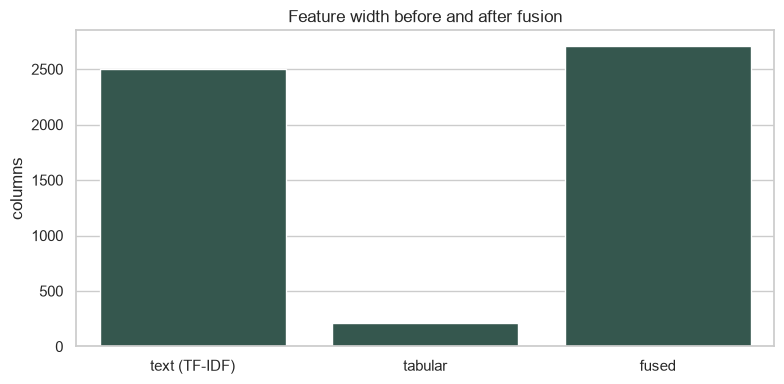

,block,n_features
0,text (TF-IDF),2500
1,tabular,213
2,fused,2713


In [4]:
width_df = pd.DataFrame(
    {
        "block": ["text (TF-IDF)", "tabular", "fused"],
        "n_features": [X_text_train.shape[1], X_tab_train.shape[1], X_train_fused.shape[1]],
    }
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=width_df, x="block", y="n_features", color="#2f5d50", ax=ax)
ax.set_title("Feature width before and after fusion")
ax.set_xlabel("")
ax.set_ylabel("columns")
plt.tight_layout()
fig.savefig(FIG_DIR / "06_fused_feature_width.png", dpi=150)
plt.show()

width_df

### What this figure shows

Fusion is dominated by the text vocabulary width. That imbalance is exactly why Phase 7 starts with **L2 regularization** — so 2,500 title tokens do not overpower 213 tabular signals.

## 3. Save fused artifacts

In [5]:
sparse.save_npz(PROC / "X_train_fused.npz", X_train_fused)
sparse.save_npz(PROC / "X_test_fused.npz", X_test_fused)
pd.DataFrame({"feature": fused_names}).to_csv(PROC / "fused_feature_names.csv", index=False)

meta = {
    "method": "scipy.sparse.hstack",
    "order": ["text", "tabular"],
    "n_train": int(X_train_fused.shape[0]),
    "n_test": int(X_test_fused.shape[0]),
    "n_features": int(X_train_fused.shape[1]),
    "n_text_features": int(X_text_train.shape[1]),
    "n_tab_features": int(X_tab_train.shape[1]),
    "train_density": float(X_train_fused.nnz / np.prod(X_train_fused.shape)),
    "test_density": float(X_test_fused.nnz / np.prod(X_test_fused.shape)),
    "train_sparse_mb": round(csr_mb(X_train_fused), 2),
    "test_sparse_mb": round(csr_mb(X_test_fused), 2),
    "targets": ["y_train.npy", "y_test.npy"],
}
with open(PROC / "fusion_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print("saved fused matrices to", PROC)
meta

saved fused matrices to /Users/koriginjasathvik/Desktop/ML_Summer_Project/data/processed


{'method': 'scipy.sparse.hstack',
 'order': ['text', 'tabular'],
 'n_train': 264728,
 'n_test': 66183,
 'n_features': 2713,
 'n_text_features': 2500,
 'n_tab_features': 213,
 'train_density': 0.0031583802411612035,
 'test_density': 0.003153961979416843,
 'train_sparse_mb': 28.28,
 'test_sparse_mb': 7.06,
 'targets': ['y_train.npy', 'y_test.npy']}

## Phase 6 takeaways

- Fused train/test matrices built with `scipy.sparse.hstack`.
- Shape matches the Phase-5 plan: `[N × 2713]`.
- Feature names preserve block prefixes: `text__*` then `tab__*`.
- Next: train L2-regularized logistic regression on `X_*_fused`.
- Notes: [`docs/fusion.md`](../docs/fusion.md).